In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

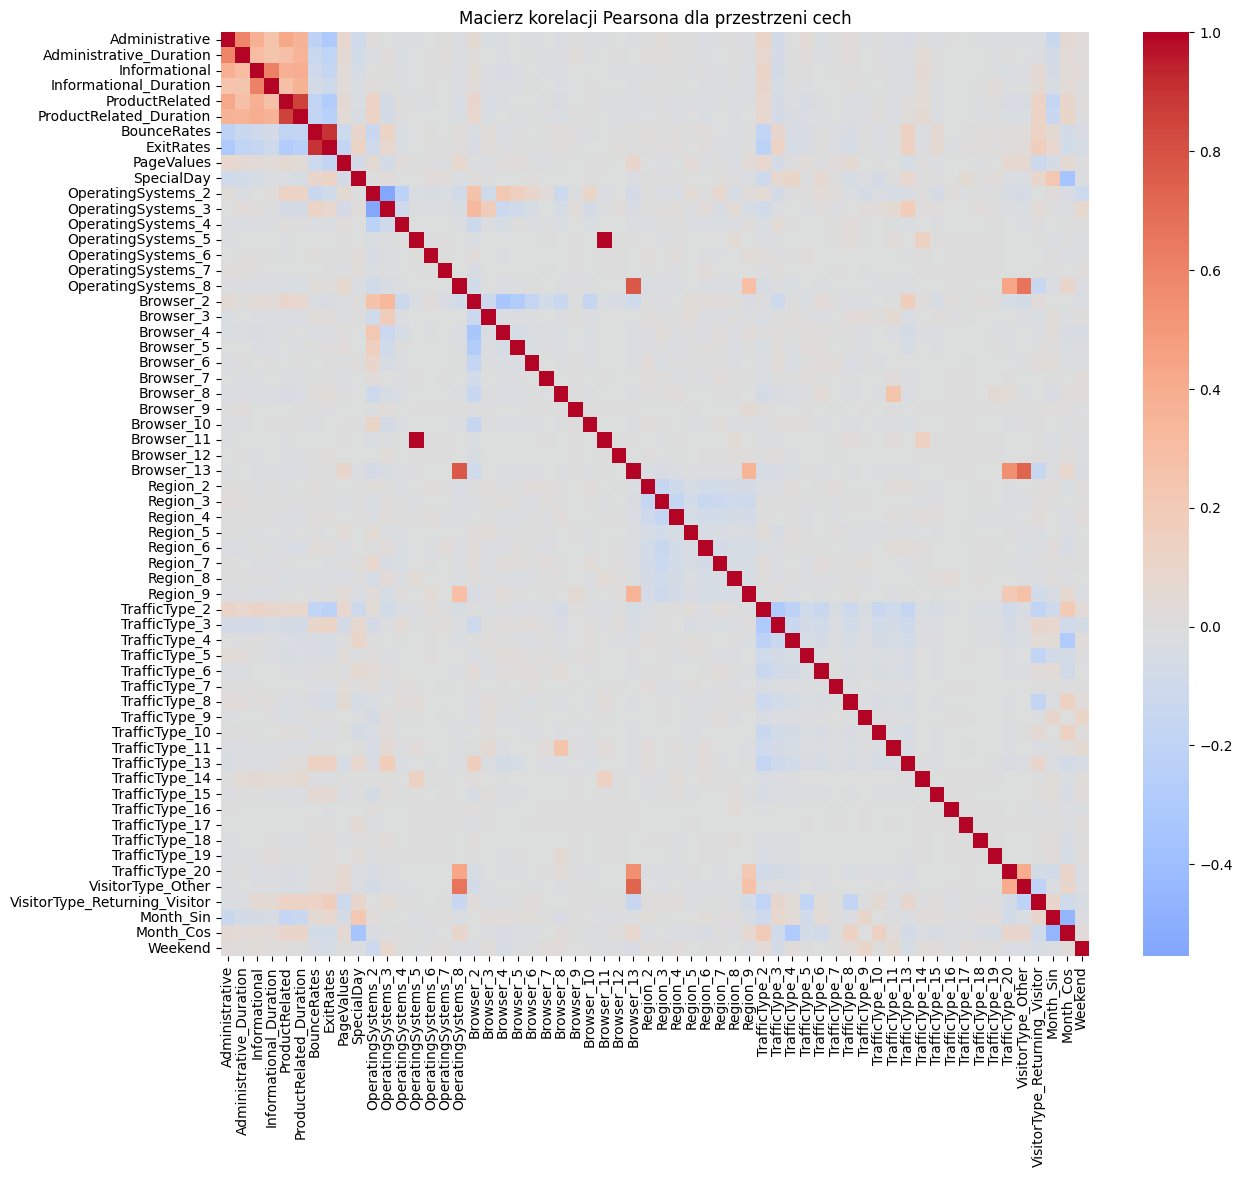

Zidentyfikowano silnie skorelowane wektory (>0.88): ['ExitRates', 'Browser_11']


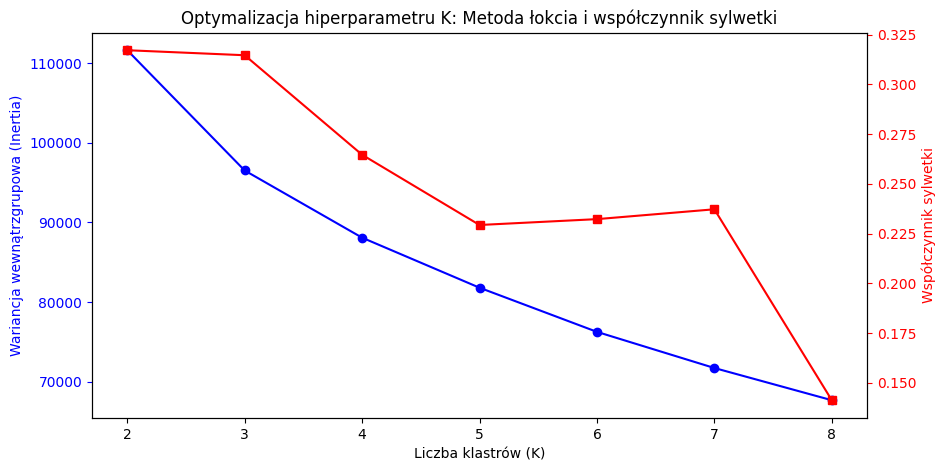

Skumulowana wariancja wyjaśniona przez 2 składowe główne: 0.3845


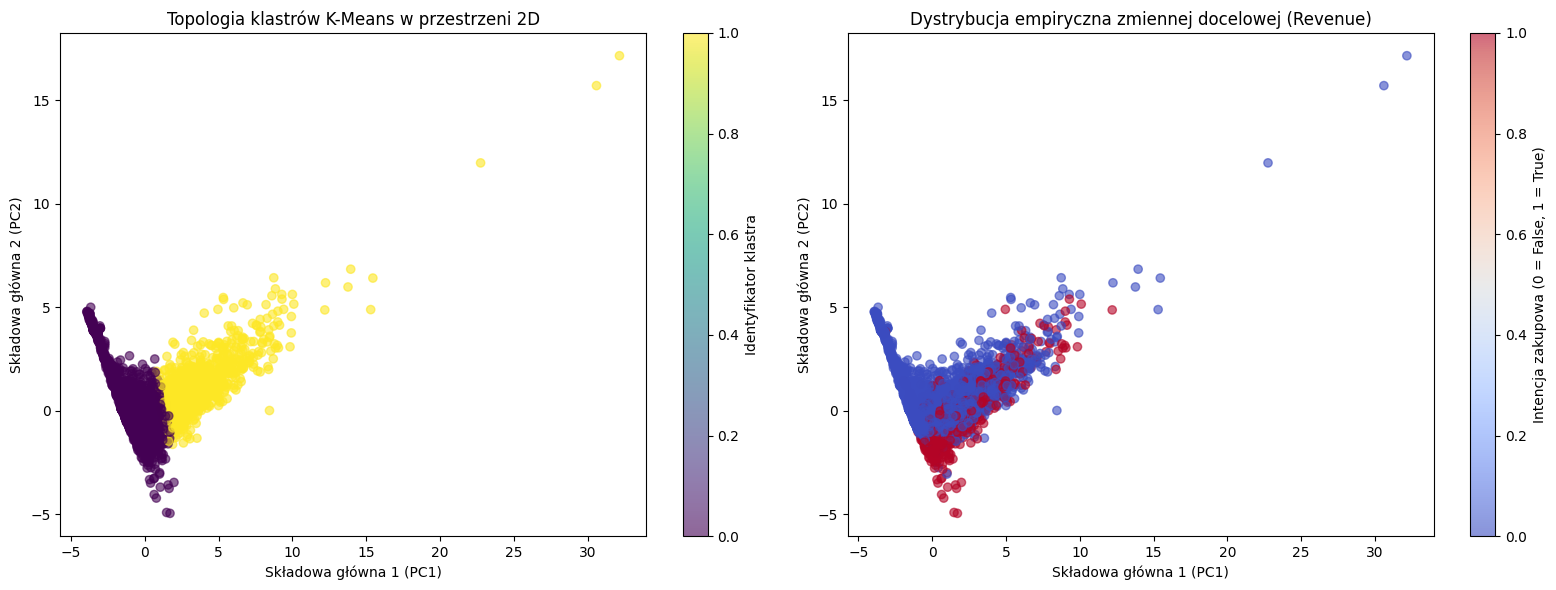

In [ ]:
df_train = pd.read_csv('online_shoppers_train_processed.csv')
X_train = df_train.drop(columns=['Revenue'])
y_train = df_train['Revenue']

# Macierz korelacji
plt.figure(figsize=(14, 12))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Macierz korelacji Pearsona dla przestrzeni cech')
plt.show()

# Automatyczna identyfikacja współliniowości (próg 0.88)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [col for col in upper_tri.columns if any(upper_tri[col] > 0.88)]
print(f"Zidentyfikowano silnie skorelowane wektory (>0.88): {high_corr_features}")

inertia = []
silhouette_scores = []
K_range = range(2, 9)

# Estymacja dla różnych wartości hiperparametru K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, cluster_labels))

# Optymalizacja K - Wykresy heurystyczne
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, 'bo-', label='Inertia (WCSS)')
ax1.set_xlabel('Liczba klastrów (K)')
ax1.set_ylabel('Wariancja wewnątrzgrupowa (Inertia)', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Współczynnik sylwetki', color='r')
ax2.tick_params('y', colors='r')

plt.title('Optymalizacja hiperparametru K: Metoda łokcia i współczynnik sylwetki')
plt.show()

# Definicja ostatecznego modelu bazując na wynikach (K=2 dla porównania z binarnym Revenue)
optimal_k = 2 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_clusters = kmeans_final.fit_predict(X_train)

# 4. Redukcja wymiarowości (PCA) i wizualizacja
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
explained_variance = pca.explained_variance_ratio_.sum()

print(f"Skumulowana wariancja wyjaśniona przez 2 składowe główne: {explained_variance:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Przypisania algorytmu K-Means
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=final_clusters, cmap='viridis', alpha=0.6)
ax1.set_xlabel('Składowa główna 1 (PC1)')
ax1.set_ylabel('Składowa główna 2 (PC2)')
ax1.set_title('Topologia klastrów K-Means w przestrzeni 2D')
fig.colorbar(scatter1, ax=ax1, label='Identyfikator klastra')

# Subplot 2: Rzeczywista dystrybucja zmiennej Revenue
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6)
ax2.set_xlabel('Składowa główna 1 (PC1)')
ax2.set_ylabel('Składowa główna 2 (PC2)')
ax2.set_title('Dystrybucja empiryczna zmiennej docelowej (Revenue)')
fig.colorbar(scatter2, ax=ax2, label='Intencja zakupowa (0 = False, 1 = True)')

plt.tight_layout()
plt.show()

Skumulowana wariancja wytłumaczona przez 2 składowe zmienne jest mniejsza niż 0.40 co sugeruje że to nie wystarcza do wyjaśnienia zmiennej.